In [1]:
import scanpy as sc
import muon as mu
import pandas as pd
import numpy as np
from scipy.stats import spearmanr
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
SEED = 42
np.random.seed(SEED)
import random
random.seed(SEED)

/ihome/ylee/yiz133/.local/lib/python3.11/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
/ihome/ylee/yiz133/.conda/envs/TCR_custom/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-04 14:23:38.931081: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-04 14:23:38.931676: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors fro

In [2]:
path = '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E2S/outs'

In [5]:
!ls '/ix1/ylee/Yifan_Zhang/CellRanger_tests/E2S/outs'

aggregate_barcodes.csv	filtered_feature_bc_matrix     raw_feature_bc_matrix
analysis		filtered_feature_bc_matrix.h5  raw_feature_bc_matrix.h5
cloupe.cloupe		metrics_summary.csv	       web_summary.html
feature_reference.csv	molecule_info.h5


# Gene analysis

In [6]:
adata_ori = sc.read_10x_h5(path+'/filtered_feature_bc_matrix.h5', gex_only=True)


In [30]:
adata = adata_ori.copy()
adata.var_names_make_unique()
adata

AnnData object with n_obs × n_vars = 1899 × 33696
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence'

In [31]:
adata.var['mt'] = adata.var_names.str.startswith('mt-')
sc.pp.calculate_qc_metrics(
    adata, 
    qc_vars=['mt'], 
    percent_top=None, 
    log1p=False, 
    inplace=True
)


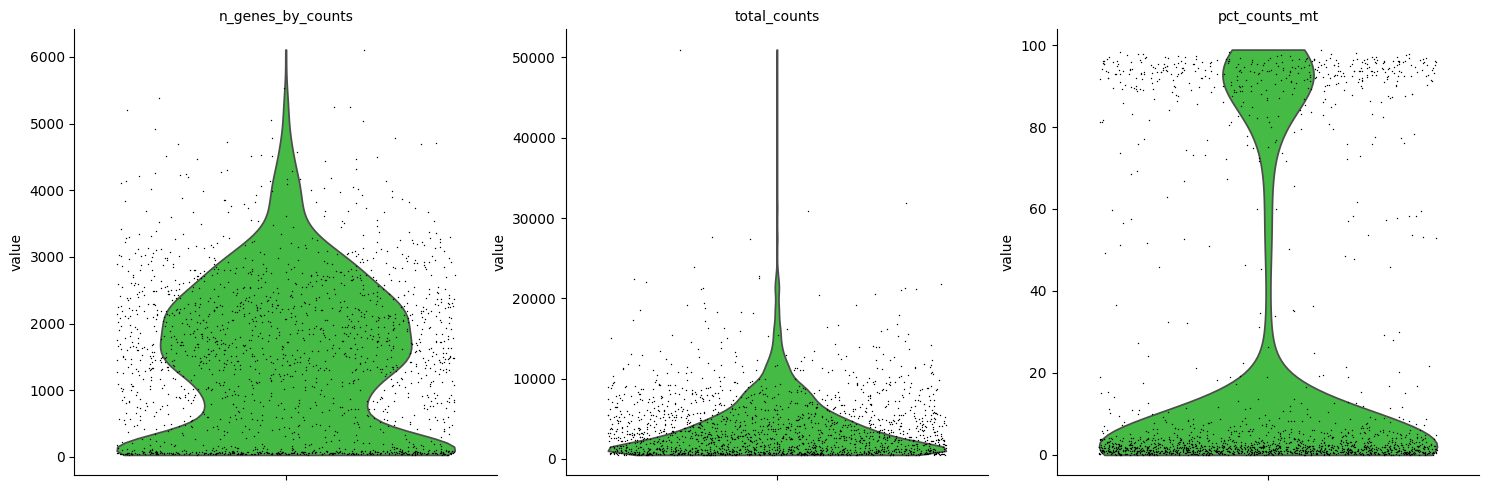

In [32]:
sc.pl.violin(
    adata,
    ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
    jitter=0.4,
    multi_panel=True,
    color='limegreen',
)

In [33]:
sc.pp.filter_cells(adata, min_genes= 100)
sc.pp.filter_cells(adata, max_genes= 6000)

sc.pp.filter_cells(adata, min_counts=1000)
sc.pp.filter_cells(adata, max_counts=20000)

sc.pp.filter_genes(adata, min_cells=50)


In [34]:
sc.pp.scrublet(adata)
adata = adata[adata.obs['predicted_doublet'] == False]

In [35]:
sc.pp.normalize_total(adata)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata,  n_top_genes=2500, )

In [36]:
adata = adata[adata.obs['pct_counts_mt'] < 25]
adata = adata[:, adata.var['highly_variable']]

In [37]:
adata

View of AnnData object with n_obs × n_vars = 1284 × 2500
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'doublet_score', 'predicted_doublet'
    var: 'gene_ids', 'feature_types', 'genome', 'pattern', 'read', 'sequence', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'scrublet', 'log1p', 'hvg'

In [38]:
def lR_to_l(adata, mapper={'leiden_R': 'leiden'}):
    for current_col_name in mapper:
        new_col_name = mapper[current_col_name]
        current_col = adata.obs[current_col_name].copy()
        adata.obs.drop(columns=current_col_name)
        adata.obs[new_col_name] = current_col
    return

def reset_colors(adata, key='leiden', use_plt=True):
    if use_plt:
        try:
            del(adata.uns['plt']['color'][key])
        except:
            pass
    else:
        try:
            del(adata.uns['%s_colors' % key])
        except:
            pass
    return

def relabel_clusts(adata, key='leiden'):
    try:
        adata.obs[key].cat
    except AttributeError:
        adata.obs[key] = adata.obs[key].astype('category')
        
    cats = adata.obs[key].cat.categories
    new_cats = [str(i) for i in range(len(cats))]
    adata.obs[key] = adata.obs[key].map(dict(zip(cats, new_cats)))
    adata.obs[key] = adata.obs[key].astype('category')
    
    reset_colors(adata, key=key)
    
    return

def clean_leiden(adata):
    lR_to_l(adata)
    relabel_clusts(adata)

In [39]:
sc.pp.pca(adata, svd_solver="arpack", n_comps=20, random_state=0)
sc.pp.neighbors(adata, n_neighbors=50, random_state=0)
sc.tl.umap(adata, min_dist=0.8, spread=0.8, random_state=0)

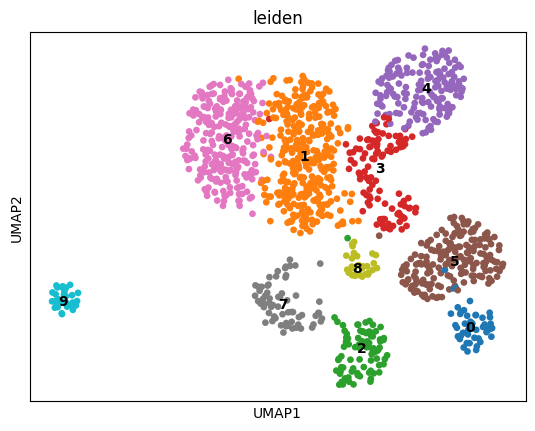

In [40]:
sc.tl.leiden(adata, resolution=0.6, n_iterations=-1, flavor='igraph', random_state=0)
sc.pl.umap(adata, color="leiden", legend_loc="on data")


In [41]:
# Run rank_genes_groups for each leiden cluster
sc.tl.rank_genes_groups(adata, 'leiden', method='wilcoxon')

# Extract top 20 genes per cluster into a DataFrame
result = adata.uns['rank_genes_groups']
groups = result['names'].dtype.names
n_genes = 20

df_top_genes = pd.DataFrame({
    group: result['names'][group][:n_genes] for group in groups
})

# Also create a version with scores and pvals
df_detailed = pd.DataFrame()
for group in groups:
    temp_df = pd.DataFrame({
        'cluster': group,
        'gene': result['names'][group][:n_genes],
        'scores': result['scores'][group][:n_genes],
        'logfoldchanges': result['logfoldchanges'][group][:n_genes],
        'pvals': result['pvals'][group][:n_genes],
        'pvals_adj': result['pvals_adj'][group][:n_genes],
    })
    df_detailed = pd.concat([df_detailed, temp_df], ignore_index=True)



In [42]:
print(f"Top {n_genes} marker genes per cluster:")
df_top_genes.T
df_top_genes.to_csv("E4_top_marker_genes_per_cluster.csv")

Top 20 marker genes per cluster:


## Markers by HVGs

In [43]:
# By HVGs
# tsne clusters
# markers = {
#     "macrophage": ["Apoe", "Mertk", "Axl", "Cebpa", "Clec7a", "Myo1e"],
#     "neutrophil": ["S100a8", "S100a9", "Lcn2", "Cxcr2", "Cxcr3"],
#     "monocyte": ["Vcan", "Ly6c2", "Ccr2","Pid1", "Cd93"],
#     "dendritic_cell": ['Msr1', 'Itgax', 'Csf2ra', 'Cd14', 'Trpm2'],
#     "CD8_exhausted": [
#         "Cd3e", "Cd3g", "Cd28", "Lck", "Trbc1", "Trbc2",                    
#         "Tox", "Cxcr6", "Il2rb",               # exhaustion/tissue-resident
#     ],
#     "CD8_effector": ["Cd3e", "Cd3g", "Cd28", "Lck", "Trbc1", "Trbc2",  
#         "Nkg7", "Ctsw", "Klrg1", "Klrc1",     # cytotoxic effector
#     ],
#     'CD4+ T': ['Cd4'],
#     'Treg': ['Foxp3', 'Il2ra'],

#     "lymphatic_endothelial": [
#         "Prox1", "Ccl21a", "Ackr2", "Emcn", "Cldn5", "Sox7", "Plvap", ]   , 

#     "Malignant_epithelial": [
#         "Trp63", "Col17a1", "Itgb4",            # basal stem cell
#         "Krt6a", "Krt6b", "Krt90", "Krt17",             # keratins
#         "Dsg3", "Dsc3", "Cldn4",                # junctions
#         "Tmprss11b", "Tmprss11d", "Tmprss11g"]  # epithelial proteases
# 'Proliferating': ['Hsp90ab1', 'Npm1', 'Eif5a', 'Ptma']
# }

# UMAP clusters
markers = {
    'Macrophage': ['Mrc1', 'C1qa', 'Apoe', 'Mertk', 'Mafb', 'Dab2'],
    'T_cell': ['Lck', 'Cd2', 'Trac', 'Trbc2', 'Gimap3', 'Gimap4'],
    'Neutrophil': ['S100a8', 'S100a9', 'Cxcr2', 'Hdc', 'G0s2', 'Csf3r'],
    'Dendritic_cell': ['Flt3', 'Cd74', 'H2-Aa', 'Fcer1g', 'Ccr7'],
    'Monocyte': ['Ccr2', 'Vcan', 'Pid1', 'S100a4', 'Plac8'],
    'B_cell': ['Ighm', 'Blnk', 'Ly6d', 'Bcl11a', 'Cd37'],
    'Proliferate': ['Hsp90ab1', 'Npm1', 'Eif5a', 'Ptma'],
}

In [44]:
umap_params = {
    'legend_loc': "on data",
    's': 30,
    'add_outline': False,
    'ncols': 3,
    'frameon': False
}

In [45]:
# Score cells for each cell type using marker genes
for cell_type, genes in markers.items():
    # Filter to genes that exist in the dataset
    valid_genes = [g for g in genes if g in adata.var_names]
    if len(valid_genes) > 0:
        sc.tl.score_genes(adata, valid_genes, score_name=f'{cell_type}_score')
        print(f"{cell_type}: {len(valid_genes)}/{len(genes)} genes found")
    else:
        print(f"{cell_type}: No genes found in dataset")

Macrophage: 5/6 genes found
T_cell: 6/6 genes found
Neutrophil: 3/6 genes found
Dendritic_cell: No genes found in dataset
Monocyte: 3/5 genes found
B_cell: 3/5 genes found
Proliferate: No genes found in dataset


In [46]:
# Calculate mean score per leiden cluster for each cell type
score_cols = [col for col in adata.obs.columns if col.endswith('_score')]
cluster_scores = adata.obs.groupby('leiden')[score_cols].mean()

# Find the cell type with highest score for each cluster
cluster_annotations = cluster_scores.idxmax(axis=1).str.replace('_score', '')
cluster_annotations.name = 'cell_type_annotation'

# Map annotations to cells
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotations)


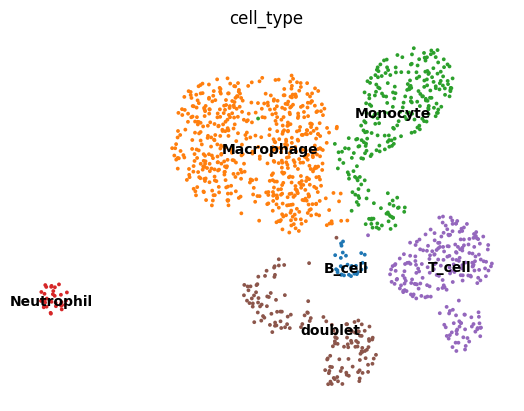

In [47]:
# Visualize the annotation on UMAP
sc.pl.umap(adata, color=['cell_type'], **umap_params)

## Canonical Markers for validation

In [48]:
# marker_dict_ref = {
#     'CD4+ T': ['Cd4'],
#     'CD8+ T': ['Cd8a','Cd8b1', 'Nkg7'],
#     'Treg': ['Foxp3', 'Il2ra'],
#     'NK': ['Ncam1', 'Nkg7', 'Gnly', 'Klrd1'],
#     'B': ['Cd19', 'Cd79a', 'Ms4a1', 'Cd79b'],
#     'Myeloid': ['Cd68', 'Itgam', 'Cd14', 'Cd33'],
#     'Monocyte': ['Cd14', 'Fcgr3a', 'Lyz'],
#     'Macrophage': ['Cd68', 'Cd163', 'Mrc1', 'Adgre1', 'Csf1r', 'Ly86'],
#     'DC': ['Fcer1a', 'Clec9a', 'Irf8'],
#     'Plasma': ['Ighg1', 'Ighg2', 'Jchain', 'Xbp1'],
#     'neutrophil':['S100a9', 'S100a8', 'Ifitm2']
# }


marker_dict_ref = {
    'Fibroblast': ['Col1a2'],
    'Macrophage': ['Cd68', 'Adgre1', 'Arg1', 'Mrc1',],
    'Neutrophil': ['S100a8', 'S100a9'],
    'Monocyte': ['Cd74', 'H2-Eb1'],
    'Dendritic': ['H2-Ab1', 'Cd74'],

    'CD4+ T': ['Cd4'],
    'CD8+ T': ['Cd8a','Cd8b1', 'Nkg7'],
    'Treg': ['Foxp3', 'Il2ra'],
    'NK': ['Ncam1', 'Nkg7', 'Gnly', 'Klrd1'],
    'B': ['Cd19', 'Cd79a', 'Ms4a1', 'Cd79b'],
    
    'Endothelial': ['Cdh5', 'Pecam1'],
    'Epithelial': ['Epcam', 'Krt5'],

    "Malignant_epithelial": [
        "Trp63", "Col17a1", "Itgb4",            # basal stem cell
        "Krt6a", "Krt6b", "Krt90", "Krt17",             # keratins
        "Dsg3", "Dsc3", "Cldn4",                # junctions
        "Tmprss11b", "Tmprss11d", "Tmprss11g"],  # epithelial proteases

    'Proliferating': ['Hsp90ab1', 'Npm1', 'Eif5a', 'Ptma']
}

[Warning] No valid markers for Fibroblast
UMAP: Macrophage (markers: ['Mrc1'])


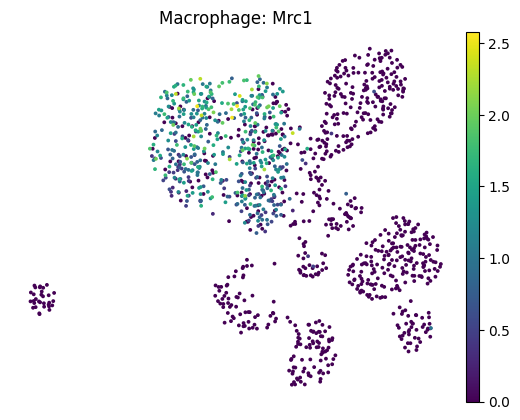

UMAP: Neutrophil (markers: ['S100a8', 'S100a9'])


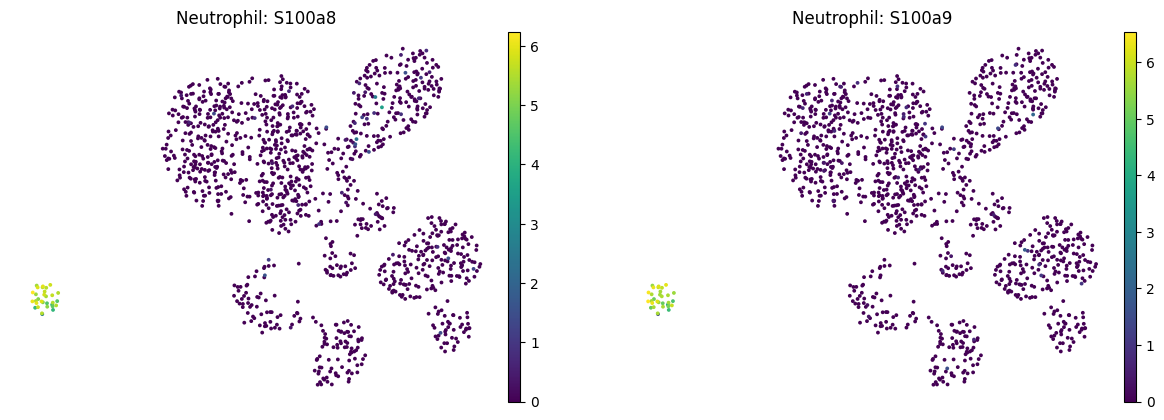

[Warning] No valid markers for Monocyte
[Warning] No valid markers for Dendritic
UMAP: CD4+ T (markers: ['Cd4'])


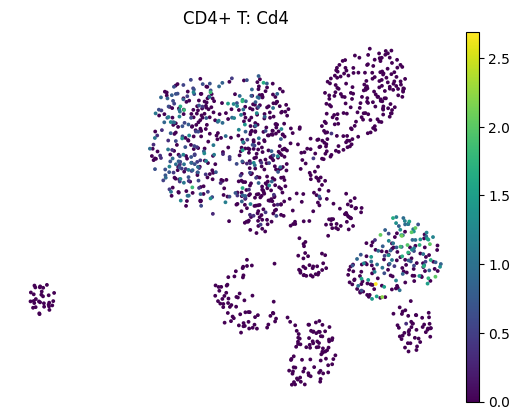

UMAP: CD8+ T (markers: ['Nkg7'])


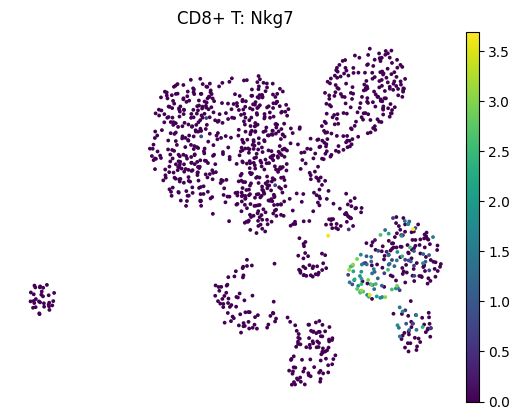

[Warning] No valid markers for Treg
UMAP: NK (markers: ['Nkg7'])


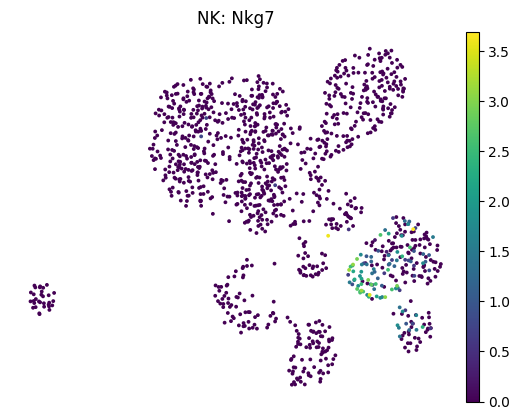

UMAP: B (markers: ['Cd79b'])


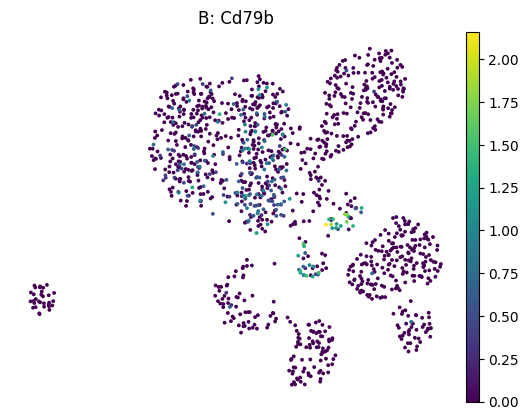

UMAP: Endothelial (markers: ['Cdh5', 'Pecam1'])


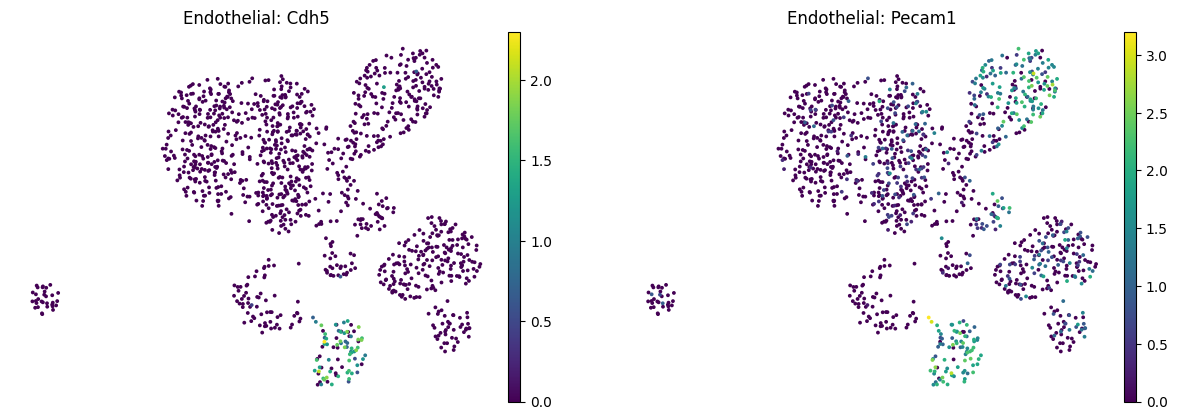

UMAP: Epithelial (markers: ['Epcam'])


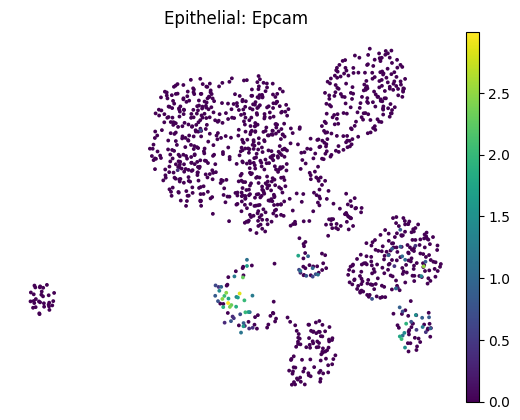

[Warning] No valid markers for Malignant_epithelial
[Warning] No valid markers for Proliferating


In [49]:
# Plot UMAP for each marker group in marker_dict_ref
for celltype, marker_list in marker_dict_ref.items():
    # Make sure markers exist in your adata.var_names (may want to filter missing ones)
    valid_markers = [gene for gene in marker_list if gene in adata.var_names]
    if not valid_markers:
        print(f"[Warning] No valid markers for {celltype}")
        continue
    print(f"UMAP: {celltype} (markers: {valid_markers})")
    sc.pl.umap(adata, color=valid_markers, title=[f"{celltype}: {gene}" for gene in valid_markers], **umap_params)

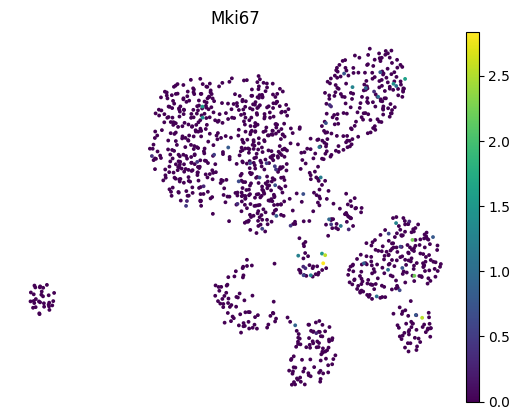

In [50]:
sc.pl.umap(adata, color='Mki67', **umap_params)

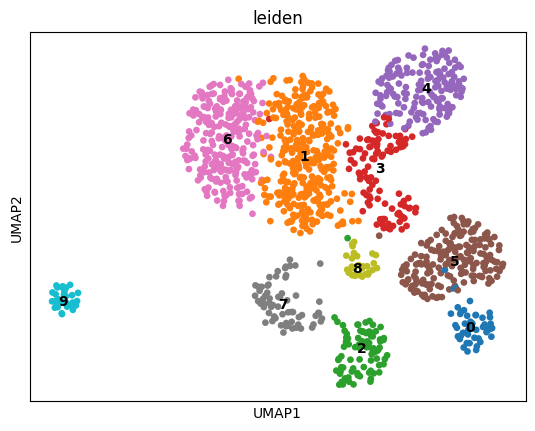

In [52]:
# aa
# run if needs

sc.tl.leiden(adata, resolution=0.2, restrict_to=('leiden', ['2']), flavor="igraph", random_state=42)
clean_leiden(adata)
sc.pl.umap(adata, color="leiden", legend_loc="on data")

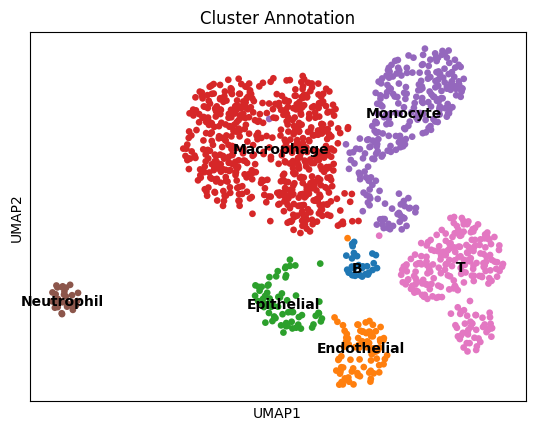

In [65]:
# Assign preliminary cluster annotation based on mapping
adata.obs['cluster_annotation'] = adata.obs['cell_type']

cluster_annotation = {
    1: "Macrophage",
    6: "Macrophage",

    9: "Neutrophil",
    8:"B",
    5:"T",
    0:"T",

    2:"Endothelial",
    7:"Epithelial",
}

# Add cluster annotation to adata.obs
# For clusters in cluster_annotation, use the mapping; otherwise keep cell_type
adata.obs['cluster_annotation'] = adata.obs.apply(
    lambda row: cluster_annotation.get(int(row['leiden']), row['cell_type']), 
    axis=1
)

# Plot the cluster annotation on UMAP
sc.pl.umap(adata, color='cluster_annotation', legend_loc='on data', title='Cluster Annotation', legend_fontsize=10)

In [66]:
adata.obs['cluster_annotation'].value_counts()

cluster_annotation
Macrophage     584
Monocyte       263
T              229
Endothelial     84
Epithelial      64
Neutrophil      31
B               29
Name: count, dtype: int64

# Annotate tumor by infercnv

In [67]:
import io

# 1. Load the GTF file (The "Local Replacement")
# Replace with the actual path to your GRCm38 genes.gtf
gtf_path = "/ix1/ylee/Yifan_Zhang/Cellranger_ref/refdata-gex-GRCm39-2024-A/genes_gtf/genes.gtf"

# Define the columns for a standard GTF
cols = ["chr", "source", "feature", "start", "end", "score", "strand", "frame", "attribute"]

# Read the file, skipping the header lines (starting with #)
gtf_df = pd.read_csv(gtf_path, sep="\t", comment="#", names=cols, low_memory=False)

# 2. Filter for 'gene' entries to get the boundaries
gtf_genes = gtf_df[gtf_df["feature"] == "gene"].copy()

# 3. Extract the Gene Symbol from the 'attribute' column 
# (This regex looks for 'gene_name "Symbol";')
gtf_genes["gene_symbol"] = gtf_genes["attribute"].str.extract('gene_name "([^"]+)"')

# 4. Create the mapping table
mapping_table = gtf_genes[["gene_symbol", "chr", "start", "end"]].dropna().drop_duplicates("gene_symbol")
mapping_table.set_index("gene_symbol", inplace=True)

# 5. Inject into your AnnData for infercnvpy
adata.var['chromosome'] = adata.var_names.map(mapping_table['chr'])
adata.var['start'] = adata.var_names.map(mapping_table['start'])
adata.var['end'] = adata.var_names.map(mapping_table['end'])

# 6. Cleanup (Remove genes that didn't find a match in the GTF)
adata = adata[:, adata.var['chromosome'].notna()].copy()

In [68]:
adata.var.loc[:, ["gene_ids", "chromosome", "start", "end"]].head()

,gene_ids,chromosome,start,end
Cops5,ENSMUSG00000025917,chr1,10094826,10108393
Cspp1,ENSMUSG00000056763,chr1,10108212,10206993
Prex2,ENSMUSG00000048960,chr1,11063689,11373905
Lactb2,ENSMUSG00000025937,chr1,13693554,13730770
Pkhd1,ENSMUSG00000043760,chr1,20128003,20688288


In [69]:
adata.obs['cluster_annotation'].cat.categories.tolist()

['B', 'Endothelial', 'Epithelial', 'Macrophage', 'Monocyte', 'Neutrophil', 'T']

In [70]:
import infercnvpy as cnv
# We provide all immune cell types as "normal cells".
cnv.tl.infercnv(
    adata,
    reference_key="cluster_annotation",
    window_size=250,
    # reference_cat=adata.obs['cluster_annotation'].cat.categories.tolist(),
    reference_cat=["Macrophage", "Neutrophil", "Epithelial"]
)

100%|██████████| 1/1 [00:00<00:00,  4.40it/s]


In [71]:
cnv.tl.pca(adata)
cnv.pp.neighbors(adata)
cnv.tl.leiden(adata)

In [72]:
cnv.tl.umap(adata)
cnv.tl.cnv_score(adata)

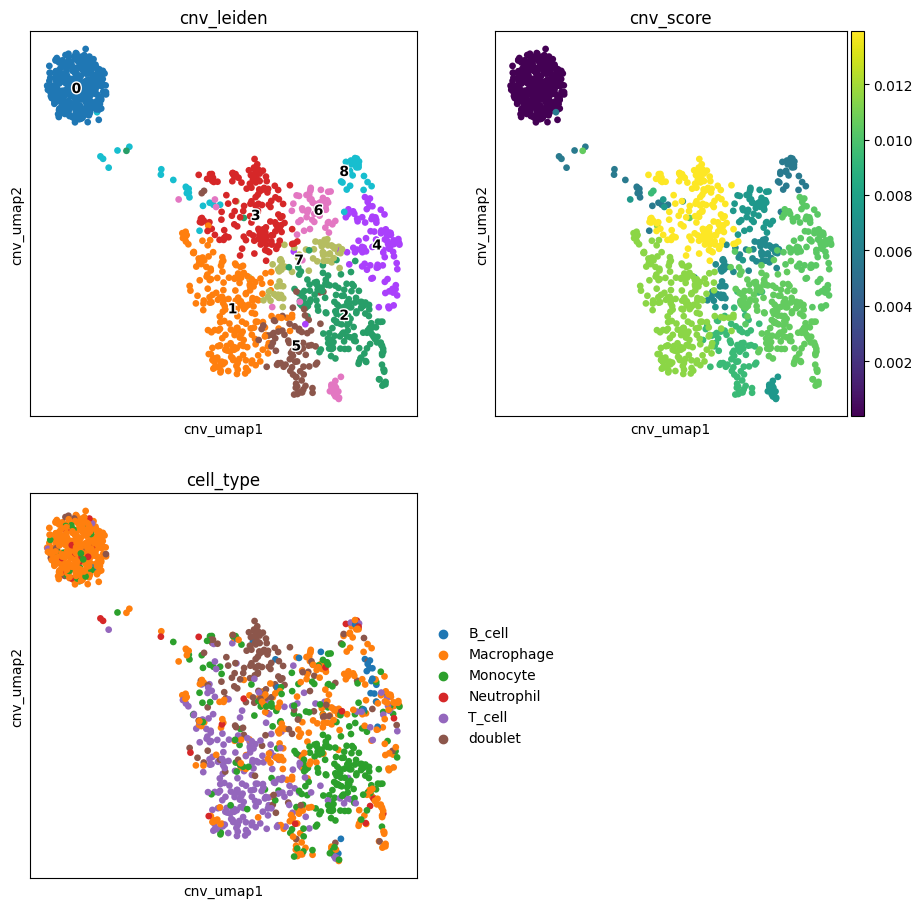

In [73]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(11, 11))
ax4.axis("off")
cnv.pl.umap(
    adata,
    color="cnv_leiden",
    legend_loc="on data",
    legend_fontoutline=2,
    ax=ax1,
    show=False,
)
cnv.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
cnv.pl.umap(adata, color="cell_type", ax=ax3)

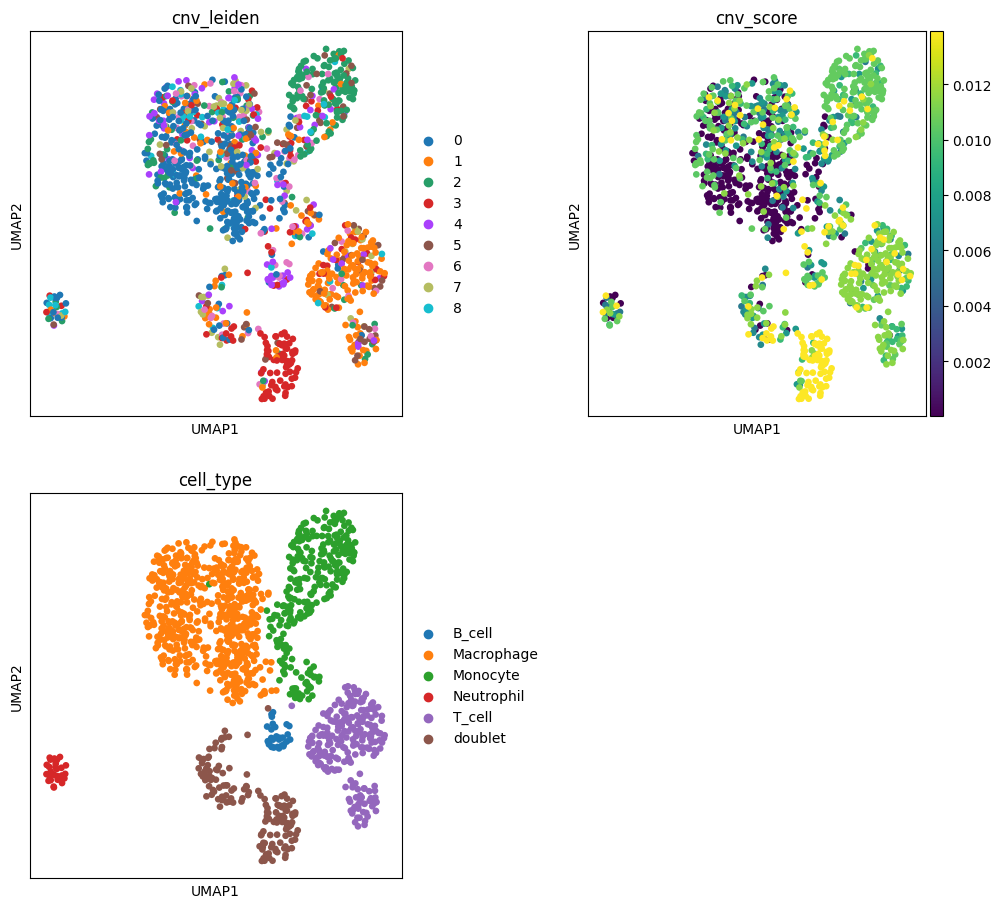

In [74]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(12, 11), gridspec_kw={"wspace": 0.5})
ax4.axis("off")
sc.pl.umap(adata, color="cnv_leiden", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_score", ax=ax2, show=False)
sc.pl.umap(adata, color="cell_type", ax=ax3)

In [77]:
adata.obs["cnv_status"] = "normal"
adata.obs.loc[adata.obs["cnv_leiden"].isin(["3"]), "cnv_status"] = (
    "tumor"
)

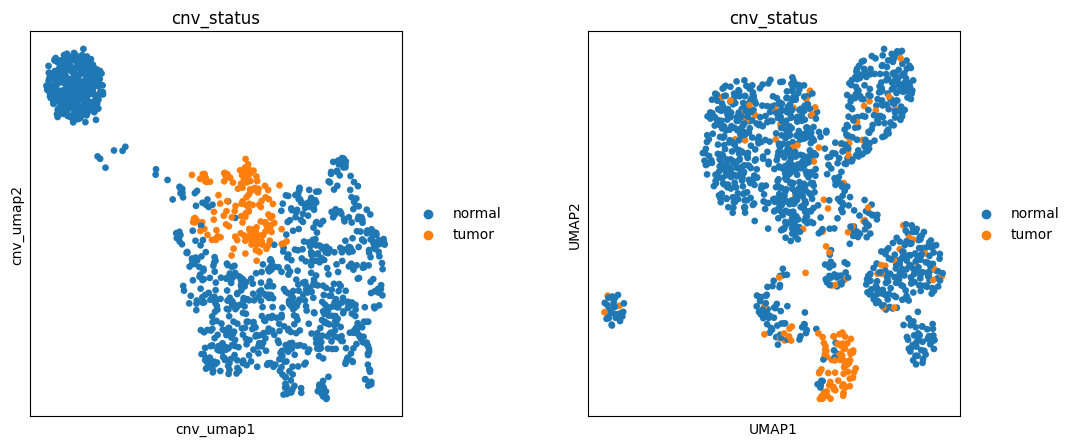

In [78]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"wspace": 0.5})
cnv.pl.umap(adata, color="cnv_status", ax=ax1, show=False)
sc.pl.umap(adata, color="cnv_status", ax=ax2)